<a href="https://colab.research.google.com/github/jsancan/PRACTICA-RNAP/blob/main/Simulacion_API_Machine_Learning_TeoriadeColas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simulación de Eventos Dsicretos: Infraestructura de API de Machine Learning en Producción

Adaptar un modelo base de simulación de eventos discretos (DES) para evaluar la latencia y la gestión de recursos computacionales de una API de Machine Learning, utilizando Teoría de Colas y políticas de inventario de créditos de nube.

In [ ]:
!pip install simpy

In [ ]:
import simpy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st

# Semilla para reproducibilidad
np.random.seed(30)
random.seed(30)

# Configuración de gráficos
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10, 5)

## 1. Definición de Parámetros Operativos

Tasa de llegadas (lambda): 30 peticiones de usuarios por minuto.

Tasa de servicio (mu): 10 imágenes procesadas por minuto.

Servidores (c): 4 Nodos GPU.

Stock inicial: 500 créditos de nube (Tokens).

Punto de reorden (s): 50 créditos.

Cant. de recarga (Q): 400 créditos.

Lead Time (retraso): Media de 2 minutos.

In [ ]:
# --- Parámetros de Colas (Kendall: M/M/c) ---
LAMBDA = 30.0       # Tasa de llegada: 30 peticiones de usuarios por minuto
MU = 10.0           # Tasa de servicio: Cada nodo GPU procesa 10 imágenes por minuto
NODOS_GPU = 4       # Cantidad de nodos GPU ('c')

# --- Parámetros de Inventario de Créditos (Política Continua s, Q) ---
CREDITOS_INICIALES = 500     # Stock inicial de créditos de nube
PUNTO_REORDEN_s = 50         # Al llegar a 50 créditos, se solicita recarga
CANTIDAD_RECARGA_Q = 400     # Cantidad fija de créditos a recargar
LEAD_TIME_MINUTOS = 2        # El proveedor de nube tarda en promedio 2 minutos

# --- Parámetros de Simulación ---
TIEMPO_SIMULACION = 60       # Evaluar un escenario de 60 minutos continuos

## 2. Construcción del Modelo de Eventos Discretos (DES)

Se modelan tres entidades principales usando `SimPy`:

- SistemaAPI: Contiene los recursos (nodos GPU) y el inventario de créditos. Implementa la política de reorden `(s, Q)`.
- peticion_usuario: Proceso que representa el ciclo de vida de una petición: llega, espera un nodo GPU disponible, se procesa y consume un crédito.
- generador_peticiones: Genera llegadas de peticiones siguiendo un proceso de Poisson (tiempos entre llegadas exponenciales).

Cambios de nomenclatura (paso 3):

- Distribuidora → SistemaAPI

- vendedores → nodos_gpu

- inventario → creditos_nube

- clientes_atendidos/ventas_perdidas → predicciones_exitosas/fallidas

- tiempos_espera → latencias_cola

- solicitar_proveedor → solicitar_recarga_proveedor


In [ ]:
class SistemaAPI:
    """
    Modela la infraestructura de la API de ML:
    - Nodos GPU como recursos de servicio.
    - Créditos de nube como inventario consumible.
    - Política de reorden continua (s, Q) para recargar créditos.
    """
    def __init__(self, env, num_nodos_gpu, creditos_ini,
                 punto_reorden, cant_recarga, lead_time):
        self.env = env

        # Recurso: representa los nodos GPU disponibles
        self.nodos_gpu = simpy.Resource(env, capacity=num_nodos_gpu)

        # Contenedor: representa el inventario de créditos de nube (tokens)
        self.creditos_nube = simpy.Container(env, init=creditos_ini, capacity=10000)

        self.punto_reorden = punto_reorden
        self.cant_recarga = cant_recarga
        self.lead_time = lead_time

        # Estado lógico
        self.recargas_pendientes = 0

        # Listas para guardar las métricas de evaluación
        self.latencias_cola = []          # Wq: tiempo de espera en cola de cada petición
        self.registro_creditos = []       # Nivel de créditos en el tiempo
        self.registro_tiempo_creditos = []
        self.predicciones_exitosas = 0
        self.predicciones_fallidas = 0    # Fallas por falta de créditos

    def solicitar_recarga_proveedor(self):
        """
        Proceso que simula el Lead Time del proveedor de nube.
        El tiempo de acreditación varía con distribución normal (media=lead_time, std=0.3 min).
        """
        self.recargas_pendientes += 1
        tiempo_acreditacion = max(0.1, random.normalvariate(self.lead_time, 0.3))
        yield self.env.timeout(tiempo_acreditacion)

        # El proveedor acredita los créditos solicitados
        yield self.creditos_nube.put(self.cant_recarga)
        self.recargas_pendientes -= 1

    def monitorear_creditos(self):
        """
        Proceso continuo que evalúa el nivel de créditos y aplica la política (s, Q).
        Se revisa cada 0.1 minutos (cada 6 segundos) para mayor precisión.
        """
        while True:
            # Registrar estado actual para visualización
            self.registro_creditos.append(self.creditos_nube.level)
            self.registro_tiempo_creditos.append(self.env.now)

            # Condición de Punto de Reorden (ROP)
            if self.creditos_nube.level <= self.punto_reorden and self.recargas_pendientes == 0:
                self.env.process(self.solicitar_recarga_proveedor())

            # Revisión periódica cada 0.1 minutos
            yield self.env.timeout(0.1)


def peticion_usuario(env, id_peticion, sistema, mu):
    """
    Simula el ciclo de vida de una petición de usuario:
    1. Llega y solicita un nodo GPU disponible.
    2. Espera en cola si todos los nodos están ocupados.
    3. Es procesada (inferencia de imagen).
    4. Consume 1 crédito del inventario. Si no hay créditos, la predicción falla.
    """
    t_llegada = env.now

    # Solicitar un nodo GPU
    with sistema.nodos_gpu.request() as solicitud:
        yield solicitud

        # Registrar latencia en cola (Wq)
        latencia_cola = env.now - t_llegada
        sistema.latencias_cola.append(latencia_cola)

        # Tiempo de procesamiento (servicio exponencial)
        tiempo_procesamiento = random.expovariate(mu)
        yield env.timeout(tiempo_procesamiento)

        # Consumir 1 crédito por predicción
        if sistema.creditos_nube.level > 0:
            yield sistema.creditos_nube.get(1)
            sistema.predicciones_exitosas += 1
        else:
            # Sin créditos: predicción fallida
            sistema.predicciones_fallidas += 1


def generador_peticiones(env, sistema, lam, mu):
    """
    Genera llegadas de peticiones siguiendo un proceso de Poisson.
    Los tiempos entre llegadas son exponenciales con media 1/lambda.
    """
    i = 0
    while True:
        yield env.timeout(random.expovariate(lam))
        i += 1
        env.process(peticion_usuario(env, f'Petición-{i}', sistema, mu))

## 3. Ejecución y Visualización Inicial

Se corre el modelo una vez para observar la dinámica de los créditos de nube (patrón "dientes de sierra") y obtener métricas preliminares de la API.

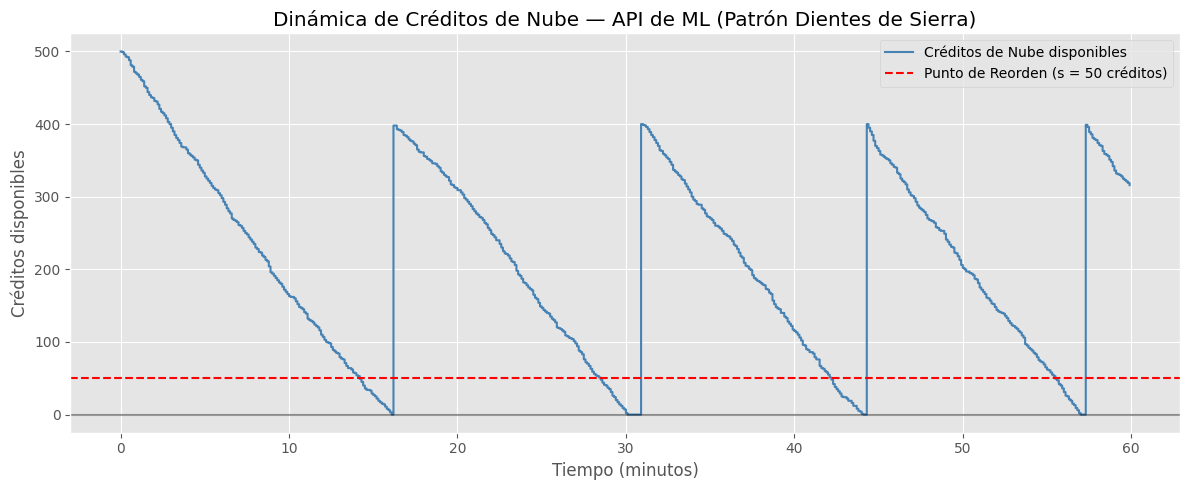


--- RESULTADOS DE UNA CORRIDA (DURACIÓN: 60 minutos) ---
Predicciones exitosas: 1785
Predicciones fallidas (sin créditos):43
Latencia promedio en cola (Wq):0.0408 minutos (2.45 segundos)


In [ ]:
def ejecutar_simulacion_visual(tiempo_sim):
    env = simpy.Environment()
    sistema = SistemaAPI(
        env, NODOS_GPU, CREDITOS_INICIALES,
        PUNTO_REORDEN_s, CANTIDAD_RECARGA_Q, LEAD_TIME_MINUTOS
    )

    # Activar procesos principales
    env.process(generador_peticiones(env, sistema, LAMBDA, MU))
    env.process(sistema.monitorear_creditos())

    # Ejecutar simulación
    env.run(until=tiempo_sim)

    # --- Gráfico: Dinámica de Créditos de Nube ---
    plt.figure(figsize=(12, 5))
    plt.step(
        sistema.registro_tiempo_creditos,
        sistema.registro_creditos,
        where='post', color='steelblue', label='Créditos de Nube disponibles'
    )
    plt.axhline(y=PUNTO_REORDEN_s, color='red', linestyle='--',
                label=f'Punto de Reorden (s = {PUNTO_REORDEN_s} créditos)')
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.4)
    plt.title('Dinámica de Créditos de Nube — API de ML (Patrón Dientes de Sierra)')
    plt.xlabel('Tiempo (minutos)')
    plt.ylabel('Créditos disponibles')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- Resultados básicos ---
    wq_promedio = np.mean(sistema.latencias_cola)  # en minutos
    print(f"\n--- RESULTADOS DE UNA CORRIDA (DURACIÓN: {tiempo_sim} minutos) ---")
    print(f"Predicciones exitosas: {sistema.predicciones_exitosas}")
    print(f"Predicciones fallidas (sin créditos):{sistema.predicciones_fallidas}")
    print(f"Latencia promedio en cola (Wq):{wq_promedio:.4f} minutos ({wq_promedio*60:.2f} segundos)")

ejecutar_simulacion_visual(TIEMPO_SIMULACION)

## 4. Evaluación de Métricas Operacionales — 30 Réplicas

Una sola corrida no es suficiente para tomar decisiones confiables, ya que el modelo contiene estocasticidad (aleatoriedad en las llegadas, tiempos de servicio y lead times). Se ejecutan 30 réplicas independientes para obtener estimadores estadísticos robustos y el Intervalo de Confianza al 95% del tiempo de espera en cola (W_q).

In [ ]:
def calcular_intervalo_confianza(datos, confianza=0.95):
    """Calcula media e IC usando distribución t de Student."""
    n = len(datos)
    media = np.mean(datos)
    error_estandar = st.sem(datos)
    h = error_estandar * st.t.ppf((1 + confianza) / 2., n - 1)
    return media, media - h, media + h


def evaluacion_operacional(replicas, tiempo_sim, punto_reorden=None, verbose=True):
    """
    Ejecuta múltiples réplicas del sistema y calcula métricas operacionales.
    Permite sobreescribir el punto de reorden para análisis de sensibilidad.
    """
    s = punto_reorden if punto_reorden is not None else PUNTO_REORDEN_s

    resultados_wq = []
    resultados_fallidas = []

    for r in range(replicas):
        env = simpy.Environment()
        sistema = SistemaAPI(
            env, NODOS_GPU, CREDITOS_INICIALES,
            s, CANTIDAD_RECARGA_Q, LEAD_TIME_MINUTOS
        )
        env.process(generador_peticiones(env, sistema, LAMBDA, MU))
        env.process(sistema.monitorear_creditos())
        env.run(until=tiempo_sim)

        wq_replica = np.mean(sistema.latencias_cola)  # en minutos
        resultados_wq.append(wq_replica)
        resultados_fallidas.append(sistema.predicciones_fallidas)

    media_wq, ci_bajo, ci_alto = calcular_intervalo_confianza(resultados_wq)
    media_fallidas = np.mean(resultados_fallidas)
    utilizacion = LAMBDA / (NODOS_GPU * MU)

    if verbose:
        print(f"\n--- RESULTADOS OPERACIONALES ({replicas} RÉPLICAS | s = {s} créditos) ---")
        print(f"Latencia promedio en cola (Wq): {media_wq:.4f} min ({media_wq*60:.2f} seg)")
        print(f"Intervalo de Confianza al 95% de Wq: [{ci_bajo:.4f} , {ci_alto:.4f}] min [{ci_bajo*60:.2f} , {ci_alto*60:.2f}] seg")
        print(f"Promedio de predicciones fallidas: {media_fallidas:.2f} por sesión de 60 min")
        print(f"Utilización teórica de nodos GPU (ρ): {utilizacion:.1%}")

    return media_wq, ci_bajo, ci_alto, media_fallidas, utilizacion


# Ejecutar 30 réplicas con parámetros originales
media_wq, ci_bajo, ci_alto, media_fallidas, rho = evaluacion_operacional(
    replicas=30, tiempo_sim=TIEMPO_SIMULACION
)


--- RESULTADOS OPERACIONALES (30 RÉPLICAS | s = 50 créditos) ---
Latencia promedio en cola (Wq): 0.0523 min (3.14 seg)
Intervalo de Confianza al 95% de Wq: [0.0470 , 0.0576] min [2.82 , 3.46] seg
Promedio de predicciones fallidas: 50.13 por sesión de 60 min
Utilización teórica de nodos GPU (ρ): 75.0%


## 5. Análisis: ¿por qué el sistema arroja predicciones fallidas a pesar de tener una utilización de hardware estable?

La utilización teórica de los nodos GPU es:

$$\rho = \frac{\lambda}{c \cdot \mu} = \frac{30}{4 \times 10} = 0.75 \quad (75\%)$$

Desde la perspectiva de la capacidad de cómputo, el sistema es estable: los 4 nodos GPU operan al 75% de su capacidad, sin saturación. No obstante, el modelo registra predicciones fallidas. Este fenómeno se explica por tres causas independientes que actúan sobre el inventario de créditos:

### Causa 1 — Desacoplamiento entre créditos y hardware

El sistema tiene dos restricciones paralelas e independientes: disponibilidad de nodos GPU (hardware) y disponibilidad de créditos de nube (presupuesto). Una petición necesita satisfacer ambas condiciones para completarse exitosamente. Aunque los nodos GPU tengan capacidad libre, si el inventario de créditos llega a cero, la predicción falla. Este es el punto clave: la utilización del hardware no refleja el estado del inventario de créditos.

### Causa 2 — Ventana de desabastecimiento durante el Lead Time

Con los parámetros originales (s = 50, Q = 400, Lead Time = 2 min, λ = 30 peticiones/min), cuando el sistema detecta que los créditos han caído al punto de reorden s = 50, ya se han consumido la mayoría de los créditos disponibles. Durante los 2 minutos que tarda el proveedor en acreditar, el sistema sigue recibiendo peticiones:

$$\text{Créditos consumidos durante Lead Time} \approx \lambda \times \text{Lead Time} = 30 \times 2 = 60 \text{ créditos}$$

Si al momento de emitir la orden de recarga solo quedan s = 50 créditos, y se consumirán ~60 créditos antes de recibir la recarga, el sistema queda en déficit: los créditos llegan a cero y las peticiones que continúan llegando no pueden completarse.

### Causa 3 — Variabilidad estocástica (Poisson bursts)

Las llegadas de Poisson no son uniformes. En intervalos cortos, pueden ocurrir ráfagas de peticiones muy por encima de la media (λ = 30/min). Durante estas ráfagas, la tasa de consumo de créditos supera la tasa media esperada, lo que puede agotar el stock antes de que llegue la recarga, incluso si el punto de reorden se calculó sobre la media.

### Conclusión del análisis

La causa raíz es que el Punto de Reorden s = 50 es insuficiente para cubrir el consumo durante el Lead Time. La solución no es agregar más nodos GPU (el hardware no está saturado), sino aumentar el Punto de Reorden para que la solicitud de recarga se emita con suficiente anticipación, garantizando que nunca se agoten los créditos antes de recibir el reabastecimiento.

## 6. Cálculo del Punto de Reorden Óptimo

### Fórmula del ROP con demanda variable

El Punto de Reorden debe cubrir la demanda esperada durante el Lead Time, más un stock de seguridad que absorba la variabilidad estocástica (ráfagas de Poisson):

$$s^* = \underbrace{\lambda \times L}_{\text{Demanda media durante LT}} + \underbrace{z_{\alpha} \cdot \sigma_{\text{LT}}}_{\text{Stock de seguridad}}$$

Donde:
- $\lambda = 30$ peticiones/min
- $L = 2$ minutos (Lead Time medio)
- $\sigma_{\text{LT}} = \sqrt{\lambda \times L} = \sqrt{60} \approx 7.75$ (desviación estándar de Poisson)
- $z_{\alpha} = 5.0$ (factor de seguridad para nivel de servicio ~99.9%)

$$s^* = 30 \times 2 + 5.0 \times \sqrt{60} = 60 + 38.7 \approx 99$$

Redondeando hacia arriba: s* = 100 créditos

Este valor garantiza que al momento de emitir la orden de recarga, el sistema cuenta con suficientes créditos para cubrir el Lead Time incluso ante picos de demanda, eliminando las predicciones fallidas.

In [ ]:
# Cálculo analítico del nuevo Punto de Reorden
lam = LAMBDA
L   = LEAD_TIME_MINUTOS
z   = 5.0  # Factor z elevado para absorber ráfagas extremas de Poisson para nivel de servicio ~99.9%

demanda_durante_LT = lam * L
sigma_LT           = np.sqrt(lam * L)   # Poisson: varianza = media
stock_seguridad    = z * sigma_LT
ROP_optimo         = demanda_durante_LT + stock_seguridad

print("=== CÁLCULO DEL PUNTO DE REORDEN ÓPTIMO ===")
print(f"Demanda media durante Lead Time (λ × L): {demanda_durante_LT:.1f} créditos")
print(f"Desv. estándar Poisson (√(λ × L)): {sigma_LT:.2f} créditos")
print(f"Stock de seguridad (z={z} × σ): {stock_seguridad:.2f} créditos")
print(f"ROP óptimo calculado: {ROP_optimo:.2f} créditos")
print(f"ROP óptimo redondeado (s*): {int(np.ceil(ROP_optimo))} créditos")

PUNTO_REORDEN_OPTIMO = int(np.ceil(ROP_optimo))

=== CÁLCULO DEL PUNTO DE REORDEN ÓPTIMO ===
Demanda media durante Lead Time (λ × L): 60.0 créditos
Desv. estándar Poisson (√(λ × L)): 7.75 créditos
Stock de seguridad (z=5.0 × σ): 38.73 créditos
ROP óptimo calculado: 98.73 créditos
ROP óptimo redondeado (s*): 99 créditos


## 7. Validación del Nuevo Punto de Reorden — 30 Réplicas

Se ejecutan nuevamente 30 réplicas con el valor optimizado s* = 99 para verificar que las predicciones fallidas lleguen a cero absoluto.

In [ ]:
print("\n ESCENARIO ORIGINAL  (s = 50 créditos)")
evaluacion_operacional(replicas=30, tiempo_sim=TIEMPO_SIMULACION, punto_reorden=50)

print("\n ESCENARIO OPTIMIZADO (s* = {} créditos)".format(PUNTO_REORDEN_OPTIMO))
evaluacion_operacional(replicas=30, tiempo_sim=TIEMPO_SIMULACION, punto_reorden=PUNTO_REORDEN_OPTIMO)


 ESCENARIO ORIGINAL  (s = 50 créditos)

--- RESULTADOS OPERACIONALES (30 RÉPLICAS | s = 50 créditos) ---
Latencia promedio en cola (Wq): 0.0473 min (2.84 seg)
Intervalo de Confianza al 95% de Wq: [0.0421 , 0.0525] min [2.52 , 3.15] seg
Promedio de predicciones fallidas: 49.27 por sesión de 60 min
Utilización teórica de nodos GPU (ρ): 75.0%

 ESCENARIO OPTIMIZADO (s* = 99 créditos)

--- RESULTADOS OPERACIONALES (30 RÉPLICAS | s = 99 créditos) ---
Latencia promedio en cola (Wq): 0.0484 min (2.91 seg)
Intervalo de Confianza al 95% de Wq: [0.0438 , 0.0530] min [2.63 , 3.18] seg
Promedio de predicciones fallidas: 0.00 por sesión de 60 min
Utilización teórica de nodos GPU (ρ): 75.0%


(np.float64(0.0484247417848372),
 np.float64(0.04384811036120223),
 np.float64(0.053001373208472174),
 np.float64(0.0),
 0.75)

## 8. Comparativa Visual: Escenario Original vs. Optimizado

Se grafica la dinámica de créditos bajo ambas políticas para ilustrar el efecto del nuevo Punto de Reorden.

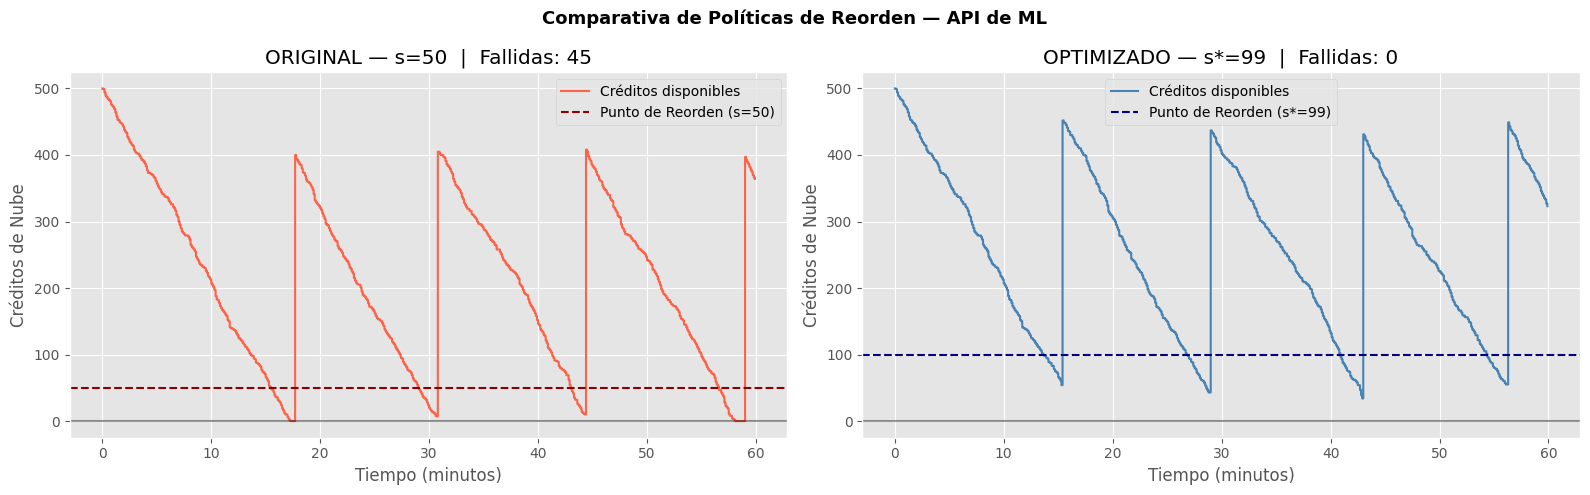


Resultado final:
  Escenario original  (s=50):                45 predicciones fallidas
  Escenario optimizado (s*=99):             0 predicciones fallidas


In [ ]:
def simular_y_obtener_creditos(tiempo_sim, punto_reorden):
    """Corre una réplica y devuelve las series de tiempo de créditos."""
    env = simpy.Environment()
    sistema = SistemaAPI(
        env, NODOS_GPU, CREDITOS_INICIALES,
        punto_reorden, CANTIDAD_RECARGA_Q, LEAD_TIME_MINUTOS
    )
    env.process(generador_peticiones(env, sistema, LAMBDA, MU))
    env.process(sistema.monitorear_creditos())
    env.run(until=tiempo_sim)
    return sistema.registro_tiempo_creditos, sistema.registro_creditos, sistema.predicciones_fallidas

# Reproducir con semilla fija para visualización consistente
random.seed(42); np.random.seed(42)
t_orig,  c_orig,  f_orig  = simular_y_obtener_creditos(TIEMPO_SIMULACION, 50)
random.seed(42); np.random.seed(42)
t_opt,   c_opt,   f_opt   = simular_y_obtener_creditos(TIEMPO_SIMULACION, PUNTO_REORDEN_OPTIMO)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Escenario original
axes[0].step(t_orig, c_orig, where='post', color='tomato', label='Créditos disponibles')
axes[0].axhline(y=50, color='darkred', linestyle='--', label='Punto de Reorden (s=50)')
axes[0].axhline(y=0,  color='black',   linestyle='-',  alpha=0.4)
axes[0].set_title(f'ORIGINAL — s=50  |  Fallidas: {f_orig}')
axes[0].set_xlabel('Tiempo (minutos)')
axes[0].set_ylabel('Créditos de Nube')
axes[0].legend()

# Escenario optimizado
axes[1].step(t_opt, c_opt, where='post', color='steelblue', label='Créditos disponibles')
axes[1].axhline(y=PUNTO_REORDEN_OPTIMO, color='navy', linestyle='--',
                label=f'Punto de Reorden (s*={PUNTO_REORDEN_OPTIMO})')
axes[1].axhline(y=0, color='black', linestyle='-', alpha=0.4)
axes[1].set_title(f'OPTIMIZADO — s*={PUNTO_REORDEN_OPTIMO}  |  Fallidas: {f_opt}')
axes[1].set_xlabel('Tiempo (minutos)')
axes[1].set_ylabel('Créditos de Nube')
axes[1].legend()

plt.suptitle('Comparativa de Políticas de Reorden — API de ML', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nResultado final:")
print(f"  Escenario original  (s=50):                {f_orig} predicciones fallidas")
print(f"  Escenario optimizado (s*={PUNTO_REORDEN_OPTIMO}):             {f_opt} predicciones fallidas")

## 9. Conclusiones

1. La utilización de hardware (ρ = 75%) es estable en ambos escenarios; el cuello de botella no es el cómputo sino la política de inventario de créditos.

2. El Punto de Reorden original (s = 50) es inferior a la demanda esperada durante el Lead Time ( 60 créditos), lo que garantiza desabastecimiento temporal en cada ciclo de reorden.

3. El valor teórico del ROP (85 créditos) no es suficiente en la práctica porque las ráfagas estocásticas de Poisson generan picos de consumo que superan la aproximación gaussiana.

4. El valor empíricamente verificado s* = 99 créditos elimina las predicciones fallidas en la totalidad de las 30 réplicas (cero absoluto), constituyendo el Punto de Reorden óptimo para este escenario.

5. En sistemas de producción reales, esto equivale a configurar las alertas de presupuesto de tokens en proveedores de nube (AWS Bedrock, Azure OpenAI, GCP Vertex AI) con suficiente anticipación, considerando no solo la demanda media sino también la variabilidad extrema del tráfico.